Reactor utility  | Iters |    MeOH prod |     CO2 conv | CO2 emission |    Preheater | Status
          (degC) |       |       (kg/h) |          (%) |       (kg/h) |         (kW) |
             235 |     5 |         5097 |        23.74 |         1115 |         7331 | OK
             236 |     4 |         5110 |        24.12 |         1093 |         7257 | OK
             237 |     4 |         5123 |        24.42 |         1078 |         7207 | OK
             238 |     3 |         5139 |        24.66 |         1065 |         7168 | OK
             239 |     3 |         5146 |        24.85 |         1057 |         7143 | OK
             240 |     4 |         5147 |           25 |         1049 |         7121 | OK
             241 |     3 |         5152 |        25.08 |         1047 |         7118 | OK
             242 |     3 |         5151 |        25.12 |         1044 |         7116 | OK
             243 |     2 |         5140 |        25.14 |         1043 |         7117 | OK
         

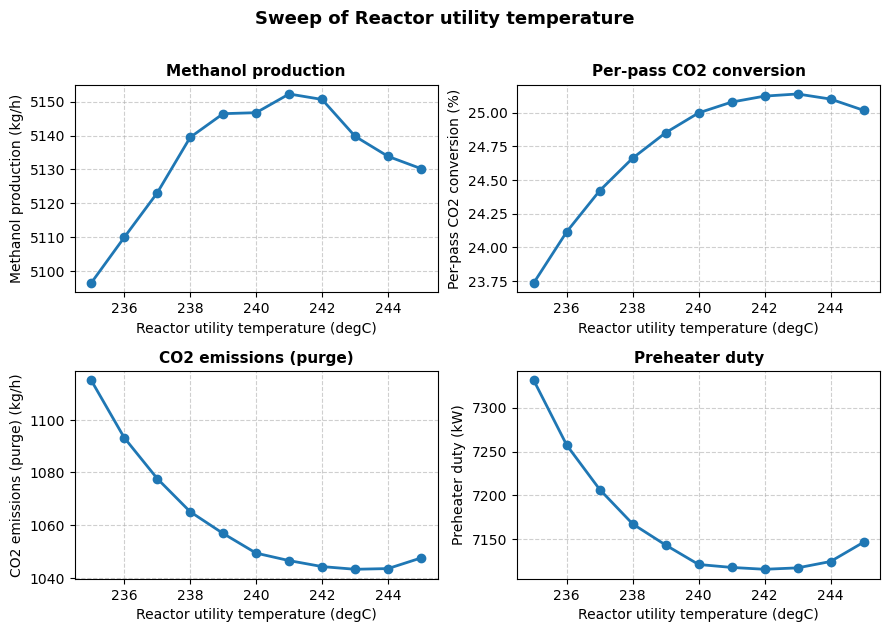

In [11]:
import numpy as np
import pandas as pd
from functools import lru_cache
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from thermo import (
    Chemical,
    ChemicalConstantsPackage,
    PropertyCorrelationsPackage,
    CEOSGas,
    CEOSLiquid,
    FlashVL,
    PRMIX,
)
from thermo.interaction_parameters import IPDB
import itertools
import os
import math
from matplotlib.lines import Line2D

species = ['methane', 'carbon monoxide', 'carbon dioxide', 'water', 'hydrogen', 'methanol']
species_names = ['CH4', 'CO', 'CO2', 'H2O', 'H2', 'MeOH']
constants, correlations = ChemicalConstantsPackage.from_IDs(species)
kijs = IPDB.get_ip_asymmetric_matrix('ChemSep PR', constants.CASs, 'kij')
eos_kwargs = {'Tcs': constants.Tcs, 'Pcs': constants.Pcs, 'omegas': constants.omegas, 'kijs': kijs}

gas = CEOSGas(PRMIX, eos_kwargs, HeatCapacityGases=correlations.HeatCapacityGases)
liquid = CEOSLiquid(PRMIX, eos_kwargs, HeatCapacityGases=correlations.HeatCapacityGases)
flasher = FlashVL(constants, correlations, gas=gas, liquid=liquid)

SCALE_F = 10000.0  # kmol/hr
SCALE_T = 300.0  # K

BASE = {
    # Reactor geometry
    'L_t': 4.0,               # m, tube length
    'd_ti': 0.058,            # m, tube inner diameter
    'N_t': 2500,              # number of tubes
    'T_util_C': 240.0,        # degC, reactor boiling-water utility temperature

    # Process
    'split_ratio': 0.95,      # fraction
    'F_r_in': None,           # kmol/hr
    'P_r_in': None,           # bar, reactor inlet pressure (None = mixer P minus preheater dP)
    'CO2_H2_ratio': None,     # mol CO2 / mol H2 in reactor feed (None = whatever the loop gives)
    'F_fresh': 853.828331498798,      # kmol/hr
    'T_fresh_C': 171.038182152794,    # degC
    'P_fresh_bar': 51.0,      # bar
    'T_ph_C': 250.0,          # degC
    'T_c_C': 60.0,            # degC
    'isen_efficiency': 0.8,

    # Costing -- global economic parameters
    'CEPCI_2001': 397,        # dimensionless
    'CEPCI_2026': 800,        # dimensionless (estimated)
    'USD_ZAR': 16.42,         # ZAR per USD
    'hps_cost_usd': 17.7,                        # USD per GJ
    'cw_cost_usd': 0.354,                        # USD per GJ
    'bfw_cost_usd': 2.45 / (2200 * 1000) * 1e6,  # USD per GJ
    'elec_cost': 3.2,         # ZAR per kWh
    'C_cat': 30,              # $ per kg
    'cat_life': 5,            # years
    'r_disc': 0.1,            # discount rate
    'n_life': 15,             # plant lifetime, years
    'plant_avail': 0.95,      # dimensionless
}

def get_x(F, T, y):
    return np.concatenate(([F / SCALE_F, T / SCALE_T], y))

def parse_x(x):
    F = max(100.0, float(x[0] * SCALE_F))  # kmol/hr
    T = max(200.0, float(x[1] * SCALE_T))  # K
    y_raw = [max(1e-12, float(val)) for val in x[2:]]  # mole fraction
    sum_y = sum(y_raw)  # mole fraction
    y = [val / sum_y for val in y_raw]  # mole fraction
    return F, T, y

def safe_lmtd(dt1, dt2):
    dt1 = max(1e-4, dt1)  # K
    dt2 = max(1e-4, dt2)  # K
    if abs(dt1 - dt2) < 1e-4:
        return dt1  # K
    return (dt1 - dt2) / np.log(dt1 / dt2)  # K

def flow_regime(Re):
    if Re >= 1e4:
        return 'Turbulent flow'
    elif Re <= 2300:
        return 'Laminar flow'
    else:
        return 'Transitional flow'

@lru_cache(maxsize=None)
def get_util_props(T_util_C):
    Temp_util_in = T_util_C + 273.15  # K

    util_sat = Chemical('Water', T=Temp_util_in)
    Press_util_in = util_sat.Psat  # Pa
    util = Chemical('Water', T=Temp_util_in, P=Press_util_in)

    Cp_util_liq = util.Cpl  # J/(kg.K)
    rho_util_liq = util.rhol  # kg/m^3
    mu_util_liq = util.mul  # Pa.s
    k_util_liq = util.kl  # W/(m.K)

    rho_util_vap = util.rhog  # kg/m^3
    mu_util_vap = util.mug  # Pa.s
    k_util_vap = util.kg  # W/(m.K)

    Hvap_util = util.Hvap  # J/kg
    sigma_util = util.sigma  # N/m

    Pr_util_liq = Cp_util_liq * mu_util_liq / k_util_liq  # dimensionless

    return (Cp_util_liq, rho_util_liq, mu_util_liq, k_util_liq,
            rho_util_vap, mu_util_vap, k_util_vap, Hvap_util, sigma_util, Pr_util_liq)

def feed_q(z_meoh, z_h2o, T_bubble, T_feed):
    meoh, h2o = Chemical('methanol'), Chemical('water')
    Cpl_meoh = meoh.HeatCapacityLiquid.T_dependent_property(T_bubble)  # J/(mol.K)
    Cpl_h2o  = h2o.HeatCapacityLiquid.T_dependent_property(T_bubble)  # J/(mol.K)
    Hvap_meoh = meoh.EnthalpyVaporization.T_dependent_property(T_bubble)  # J/mol
    Hvap_h2o  = h2o.EnthalpyVaporization.T_dependent_property(T_bubble)  # J/mol

    Cpl_mix  = z_meoh * Cpl_meoh + z_h2o * Cpl_h2o  # J/(mol.K)
    Hvap_mix = z_meoh * Hvap_meoh + z_h2o * Hvap_h2o  # J/mol

    return 1 + Cpl_mix * (T_bubble - T_feed) / Hvap_mix  # dimensionless

def nrtl(T_guess, P, x_1, params, ant1, ant2):
    R = 8.3145  # J/(mol.K)
    A_12, A_21, alpha_12 = params  # A_12, A_21 in J/mol; alpha_12 dimensionless
    A1, B1, C1 = ant1  # dimensionless, K, K
    A2, B2, C2 = ant2  # dimensionless, K, K

    def solve(T):
        T = float(T[0])  # K
        tau_12 = A_12 / (R * T)  # dimensionless
        tau_21 = A_21 / (R * T)  # dimensionless

        G_12 = np.exp(-alpha_12 * tau_12)  # dimensionless
        G_21 = np.exp(-alpha_12 * tau_21)  # dimensionless

        gamma_1 = np.exp(((1 - x_1) ** 2) * (tau_21 * (G_21 / (x_1 + (1 - x_1) * G_21)) ** 2 + tau_12 * G_12 / (((1 - x_1) + x_1 * G_12) ** 2)))  # dimensionless
        gamma_2 = np.exp((x_1 ** 2) * (tau_12 * (G_12 / ((1 - x_1) + x_1 * G_12)) ** 2 + tau_21 * G_21 / ((x_1 + (1 - x_1) * G_21) ** 2)))  # dimensionless

        Psat_1 = 10 ** (A1 - (B1 / (T + C1))) * 1e5  # Pa
        Psat_2 = 10 ** (A2 - (B2 / (T + C2))) * 1e5  # Pa

        eqn = -P + x_1 * gamma_1 * Psat_1 + (1 - x_1) * gamma_2 * Psat_2  # Pa
        return eqn

    guess = [T_guess]  # K
    T_ans = fsolve(solve, guess)
    T = T_ans[0]  # K

    tau_12 = A_12 / (R * T)  # dimensionless
    tau_21 = A_21 / (R * T)  # dimensionless

    G_12 = np.exp(-alpha_12 * tau_12)  # dimensionless
    G_21 = np.exp(-alpha_12 * tau_21)  # dimensionless

    gamma_1 = np.exp(((1 - x_1) ** 2) * (tau_21 * (G_21 / (x_1 + (1 - x_1) * G_21)) ** 2 + tau_12 * G_12 / (((1 - x_1) + x_1 * G_12) ** 2)))  # dimensionless
    gamma_2 = np.exp((x_1 ** 2) * (tau_12 * (G_12 / ((1 - x_1) + x_1 * G_12)) ** 2 + tau_21 * G_21 / ((x_1 + (1 - x_1) * G_21) ** 2)))  # dimensionless

    Psat_1 = 10 ** (A1 - (B1 / (T + C1))) * 1e5  # Pa
    Psat_2 = 10 ** (A2 - (B2 / (T + C2))) * 1e5  # Pa

    K_1 = gamma_1 * Psat_1 / P  # dimensionless
    K_2 = gamma_2 * Psat_2 / P  # dimensionless

    alpha = K_1 / K_2  # dimensionless
    y_1 = K_1 * x_1 / (K_1 * x_1 + K_2 * (1 - x_1))  # mole fraction
    y_2 = 1 - y_1  # mole fraction

    return T, y_1, y_2, alpha

def pure_phase_enth(name, T, T_ref=298.15):
    chem = Chemical(name)
    Cpl, Cpg, Hvap, Tb = chem.HeatCapacityLiquid, chem.HeatCapacityGas, chem.EnthalpyVaporization, chem.Tb
    Hl = Cpl.T_dependent_property_integral(T_ref, T)  # J/mol
    Hg = Cpl.T_dependent_property_integral(T_ref, Tb) + Hvap.T_dependent_property(Tb) + Cpg.T_dependent_property_integral(Tb, T)  # J/mol
    return Hl, Hg

def run_loop(F_guess, T_guess, y_guess, p, loop_only=False):
    L_t, d_ti, N_t = p['L_t'], p['d_ti'], p['N_t']  # m, m, dimensionless
    T_util_C, split_ratio = p['T_util_C'], p['split_ratio']  # degC, dimensionless
    CEPCI_2001, CEPCI_2026, USD_ZAR = p['CEPCI_2001'], p['CEPCI_2026'], p['USD_ZAR']
    hps_cost = p['hps_cost_usd'] * USD_ZAR  # ZAR per GJ
    cw_cost = p['cw_cost_usd'] * USD_ZAR  # ZAR per GJ
    bfw_cost = p['bfw_cost_usd'] * USD_ZAR  # ZAR per GJ
    elec_cost, C_cat, cat_life = p['elec_cost'], p['C_cat'], p['cat_life']
    r_disc, n_life, plant_avail = p['r_disc'], p['n_life'], p['plant_avail']

    split = split_ratio  # dimensionless

    # 1. Fresh Syngas
    T_fresh = p['T_fresh_C'] + 273.15  # K
    P_fresh = p['P_fresh_bar'] * 1e5  # Pa
    F_fresh = p['F_fresh']  # kmol/hr
    y_fresh = [0.016298183, 0.009369947, 0.21667755, 0.005354161, 0.752300158, 0]  # mole fraction

    # 2. Recycle Stream
    T_recycle = T_guess  # K
    P_recycle = P_fresh  # Pa
    F_recycle = F_guess  # kmol/hr
    y_recycle = y_guess  # mole fraction

    T_recycle_in, P_recycle_in, F_recycle_in = T_recycle, P_recycle, F_recycle  # K, Pa, kmol/hr
    y_recycle_in = list(y_recycle)  # mole fraction

    # 3. Mixer
    fresh = flasher.flash(T=T_fresh, P=P_fresh, zs=y_fresh)
    recycle = flasher.flash(T=T_recycle, P=P_recycle, zs=y_recycle)

    H_fresh, H_recycle = fresh.H(), recycle.H()  # J/mol
    F_mix = F_fresh + F_recycle if p['F_r_in'] is None else p['F_r_in']  # kmol/hr

    y_mix = [max(1e-12, float((F_fresh * y_fresh[i] + F_recycle * y_recycle[i]) / F_mix)) for i in range(len(y_fresh))]  # mole fraction
    sum_y = sum(y_mix)  # mole fraction
    y_mix = [val / sum_y for val in y_mix]  # mole fraction

    # Optional CO2/H2 ratio specification: CO2 + H2 total is held fixed and re-split,
    # so CH4, CO, H2O and MeOH keep their loop values and the composition still sums to 1
    if p['CO2_H2_ratio'] is not None:
        S_co2_h2 = y_mix[2] + y_mix[4]  # mole fraction (CO2 + H2)
        y_mix[2] = S_co2_h2 * p['CO2_H2_ratio'] / (1 + p['CO2_H2_ratio'])  # mole fraction CO2
        y_mix[4] = S_co2_h2 / (1 + p['CO2_H2_ratio'])  # mole fraction H2

    H_mix = (F_fresh * H_fresh + F_recycle * H_recycle) / F_mix  # J/mol
    P_mix = min(P_fresh, P_recycle)  # Pa

    mix = flasher.flash(P=P_mix, H=H_mix, zs=y_mix)
    T_mix = mix.T  # K

    # 4. Preheater
    T_ph_util_in = 260 + 273.15  # K
    T_ph_util_out = 260 + 273.15  # K
    T_ph = p['T_ph_C'] + 273.15  # K
    P_ph = P_mix - 0.3e5  # Pa

    ph = flasher.flash(T=T_ph, P=P_ph, zs=y_mix)
    H_ph = ph.H()  # J/mol

    avg_density_ph = (mix.rho_mass() + ph.rho_mass()) / 2  # kg/m^3
    avg_moldensity_ph = (mix.rho() + ph.rho()) / 2  # mol/m^3
    avg_visc_ph = (mix.mu() + ph.mu()) / 2  # Pa.s
    avg_k_ph = (mix.k() + ph.k()) / 2  # W/(m.K)
    avg_Cp_ph = (mix.Cp_mass() + ph.Cp_mass()) / 2  # J/(kg.K)

    LMTD_ph = safe_lmtd(T_ph_util_in - T_ph, T_ph_util_out - T_mix)  # K
    Q_ph = abs(H_mix - H_ph) * F_mix / 3.6  # W

    d_ph_ti, u_ph, h_ph_o = 0.020, 20, 5000  # m, m/s, W/(m^2.K)
    Re_ph = avg_density_ph * d_ph_ti * u_ph / avg_visc_ph  # dimensionless
    Pr_ph = avg_Cp_ph * avg_visc_ph / avg_k_ph  # dimensionless
    Nu_ph = 0.023 * (Re_ph ** 0.8) * (Pr_ph ** 0.4)  # dimensionless
    h_ph_i = avg_k_ph * Nu_ph / d_ph_ti  # W/(m^2.K)
    U_ph = 1 / ((1 / h_ph_i) + (1 / h_ph_o))  # W/(m^2.K)
    ph_regime = flow_regime(Re_ph)

    A_ph = Q_ph / (U_ph * LMTD_ph)  # m^2
    V_mix = F_mix / (3.6 * avg_moldensity_ph)  # m^3/s
    N_ph_t = V_mix / (u_ph * np.pi / 4 * (d_ph_ti ** 2))  # dimensionless
    L_ph_t = A_ph / (np.pi * d_ph_ti * N_ph_t)  # m

    f_ph_D = 0.3164 * (Re_ph ** -0.25)  # dimensionless
    P_ph_drop = f_ph_D * L_ph_t * avg_density_ph * (u_ph ** 2) / (d_ph_ti * 2)  # Pa

    T_rfeed = T_ph  # K
    P_rfeed = P_mix - P_ph_drop if p['P_r_in'] is None else p['P_r_in'] * 1e5  # Pa
    y_rfeed = y_mix  # mole fraction

    # 5. Multitubular PBR Reactor
    y0 = [float(x * F_mix / 3.6) for x in y_rfeed] + [float(T_rfeed), float(P_rfeed)]

    # Mole balance
    wall_thickness = 0.002  # m
    d_to = d_ti + 2 * wall_thickness  # m
    d_p = 0.00542  # m
    L_p = 0.0052  # m
    L_char = d_p * L_p / (2 * d_p + 4 * L_p)  # m
    A_r_c = (np.pi / 4) * (d_ti ** 2)  # m^2

    A1, A2, A3, A4, A5 = 0.499, 6.62e-11, 3453.38, 1.07, 1.22e10  # kinetic pre-exponential factors
    B1, B2, B3, B4, B5 = 17197, 124119, 0, 36696, -94765  # J/mol
    R = 8.3145  # J/(mol.K)

    # Energy balance
    R_fi, R_fo, k_wall, a_L = 0.00015, 0.00015, 40, np.pi * d_to  # (m^2.K)/W, (m^2.K)/W, W/(m.K), m^2/m

    delHrxn1_298 = -49.7e3  # J/mol
    delHrxn2_298 = 41.5e3  # J/mol

    co = Chemical('Carbon monoxide', T=T_rfeed, P=P_rfeed)
    co2 = Chemical('Carbon dioxide', T=T_rfeed, P=P_rfeed)
    h2o = Chemical('Water', T=T_rfeed, P=P_rfeed)
    h2 = Chemical('Hydrogen', T=T_rfeed, P=P_rfeed)
    ch3oh = Chemical('Methanol', T=T_rfeed, P=P_rfeed)

    Cp_B = co.Cpgm  # J/(mol.K)
    Cp_C = co2.Cpgm  # J/(mol.K)
    Cp_D = h2o.Cpgm  # J/(mol.K)
    Cp_E = h2.Cpgm  # J/(mol.K)
    Cp_F = ch3oh.Cpgm  # J/(mol.K)

    delCprxn1 = Cp_F + Cp_D - Cp_C - 3 * Cp_E  # J/(mol.K)
    delCprxn2 = Cp_B + Cp_D - Cp_C - Cp_E  # J/(mol.K)

    delHrxn1 = delHrxn1_298 + delCprxn1 * (T_rfeed - 298.15)  # J/mol
    delHrxn2 = delHrxn2_298 + delCprxn2 * (T_rfeed - 298.15)  # J/mol

    Temp_util_in = T_util_C + 273.15  # K

    (Cp_util_liq, rho_util_liq, mu_util_liq, k_util_liq,
     rho_util_vap, mu_util_vap, k_util_vap, Hvap_util, sigma_util, Pr_util_liq) = get_util_props(T_util_C)

    g = 9.807  # m/s^2
    C_sf = 0.013  # dimensionless
    n_rohsenow = 1.0  # dimensionless

    # Momentum balance
    void = 0.39  # dimensionless
    tort = 3  # dimensionless
    particle_density = 1770  # kg/m^3
    d_pore = 15e-9  # m
    bed_density = particle_density * (1 - void)  # kg/m^3

    def reactor(L, y):
        FA, FB, FC, FD, FE, FF, T, P = y  # mol/s (flows), K (temp), Pa (pressure)
        FA, FB, FC, FD, FE, FF = [max(1e-12, val) for val in (FA, FB, FC, FD, FE, FF)]  # mol/s
        T = max(200.0, float(T))  # K
        P = max(1e5, float(P))  # Pa

        F_tot = FA + FB + FC + FD + FE + FF  # mol/s
        y_L = [FA / F_tot, FB / F_tot, FC / F_tot, FD / F_tot, FE / F_tot, FF / F_tot]  # mole fraction

        mix_rx = flasher.flash(T=T, P=P, zs=y_L)
        mix_moldensity = mix_rx.rho()  # mol/m^3
        mix_density = mix_rx.rho_mass()  # kg/m^3
        mix_visc = mix_rx.mu()  # Pa.s
        mix_k = mix_rx.k()  # W/(m.K)
        mix_molCp = mix_rx.Cp()  # J/(mol.K)

        # Mole balance
        pA, pB, pC = FA * P / (F_tot * 1e5), FB * P / (F_tot * 1e5), FC * P / (F_tot * 1e5)  # bar
        pD, pE, pF = FD * P / (F_tot * 1e5), FE * P / (F_tot * 1e5), FF * P / (F_tot * 1e5)  # bar

        K1 = 10 ** (3066 / T - 10.592)  # bar^-2
        K3 = 1 / (10 ** (-2073 / T + 2.029))  # dimensionless

        X1, X2 = A1 * np.exp(B1 / (R * T)), A2 * np.exp(B2 / (R * T))  # kinetic parameters
        X3, X4 = A3 * np.exp(B3 / (R * T)), A4 * np.exp(B4 / (R * T))  # kinetic parameters
        X5 = A5 * np.exp(B5 / (R * T))  # kinetic parameters

        r1_int = ((X4 * pC * pE * (1 - (1 / K1) * (pD * pF / ((pE ** 3) * pC)))) / ((1 + X3 * (pD / pE) + X1 * (pE ** 0.5) + X2 * pD) ** 3))  # mol/(kg_cat.s)
        r2_int = (X5 * pC * (1 - K3 * (pD * pB / (pC * pE))) / (1 + X3 * (pD / pE) + X1 * (pE ** 0.5) + X2 * pD))  # mol/(kg_cat.s)

        Q = F_tot / mix_moldensity  # m^3/s
        u_sf = Q / (N_t * A_r_c)  # m/s

        Re_p = mix_density * d_p * u_sf / mix_visc  # dimensionless

        y_r = np.maximum(y_L, 1e-12)  # mole fraction
        CC = FC / Q  # mol/m^3

        D_CA = 1.013e-2 * T ** 1.75 * (1 / 44 + 1 / 16) ** 0.5 / (P * (26.9 ** (1 / 3) + 24.42 ** (1 / 3)) ** 2)  # m^2/s
        D_CB = 1.013e-2 * T ** 1.75 * (1 / 44 + 1 / 28) ** 0.5 / (P * (26.9 ** (1 / 3) + 18.9 ** (1 / 3)) ** 2)  # m^2/s
        D_CD = 1.013e-2 * T ** 1.75 * (1 / 44 + 1 / 18) ** 0.5 / (P * (26.9 ** (1 / 3) + 12.7 ** (1 / 3)) ** 2)  # m^2/s
        D_CE = 1.013e-2 * T ** 1.75 * (1 / 44 + 1 / 2) ** 0.5 / (P * (26.9 ** (1 / 3) + 7.07 ** (1 / 3)) ** 2)  # m^2/s
        D_CF = 1.013e-2 * T ** 1.75 * (1 / 44 + 1 / 32) ** 0.5 / (P * (26.9 ** (1 / 3) + 29.9 ** (1 / 3)) ** 2)  # m^2/s

        D_Cm = (1 - y_r[2]) / (y_r[0] / D_CA + y_r[1] / D_CB + y_r[3] / D_CD + y_r[4] / D_CE + y_r[5] / D_CF)  # m^2/s

        D_CK = (d_pore / 3) * (8 * R * T / (np.pi * 44e-3)) ** 0.5  # m^2/s
        D_Cp = 1 / (1 / D_CK + 1 / D_Cm)  # m^2/s
        D_Ceff = void * D_Cp / tort  # m^2/s

        thiele_1 = L_char * (np.abs(r1_int) * particle_density / (D_Ceff * CC)) ** 0.5  # dimensionless
        thiele_2 = L_char * (np.abs(r2_int) * particle_density / (D_Ceff * CC)) ** 0.5  # dimensionless

        eta_1 = 3 / thiele_1 * (1 / np.tanh(thiele_1) - 1 / thiele_1) if thiele_1 > 1e-6 else 1.0  # dimensionless
        eta_2 = 3 / thiele_2 * (1 / np.tanh(thiele_2) - 1 / thiele_2) if thiele_2 > 1e-6 else 1.0  # dimensionless

        r1 = eta_1 * r1_int  # mol/(kg_cat.s)
        r2 = eta_2 * r2_int  # mol/(kg_cat.s)

        dFAdL = N_t * bed_density * A_r_c * (0)  # mol/(m.s)
        dFBdL = N_t * bed_density * A_r_c * (r2)  # mol/(m.s)
        dFCdL = -N_t * bed_density * A_r_c * (r1 + r2)  # mol/(m.s)
        dFDdL = N_t * bed_density * A_r_c * (r1 + r2)  # mol/(m.s)
        dFEdL = -N_t * bed_density * A_r_c * (3 * r1 + r2)  # mol/(m.s)
        dFFdL = N_t * bed_density * A_r_c * (r1)  # mol/(m.s)

        # Energy balance
        Nu = 3.5 * (Re_p ** 0.7) * np.exp(-4.6 * (d_p / d_ti))  # dimensionless
        h_i = mix_k * Nu / d_ti  # W/(m^2.K)

        q_flux = mu_util_liq * Hvap_util * (g * (rho_util_liq - rho_util_vap) / sigma_util) ** 0.5 * (Cp_util_liq * (T - Temp_util_in) / (C_sf * Hvap_util * Pr_util_liq ** n_rohsenow)) ** 3  # W/m^2
        h_o = q_flux / (T - Temp_util_in)  # W/(m^2.K)

        U_L = 1 / ((d_to / (d_ti * h_i)) + (d_to * R_fi / d_ti) + (d_to * np.log(d_to / d_ti) / (2 * k_wall)) + R_fo + 1 / h_o)  # W/(m^2.K)

        H_rxn = r1 * delHrxn1 + r2 * delHrxn2  # J/(kg_cat.s)
        H_flow = F_tot * mix_molCp  # W/K

        dTdL = N_t * (U_L * a_L * (Temp_util_in - T) - bed_density * A_r_c * H_rxn) / (H_flow)  # K/m

        # Momentum balance
        dPdL = -150 * ((1 - void) ** 2) * mix_visc * u_sf / ((void ** 3) * (d_p ** 2)) - 1.75 * (1 - void) * mix_density * (u_sf ** 2) / ((void ** 3) * (d_p))  # Pa/m

        return dFAdL, dFBdL, dFCdL, dFDdL, dFEdL, dFFdL, dTdL, dPdL

    L_t_span = np.linspace(0, L_t, 500)  # m
    soln = solve_ivp(reactor, (0, L_t), y0, method='LSODA', dense_output=True, rtol=1e-5, atol=1e-7)
    if not soln.success:
        raise RuntimeError(f"ODE integration failed: {soln.message}")

    FA_r, FB_r, FC_r, FD_r, FE_r, FF_r, T_r, P_r = soln.sol(L_t_span)  # mol/s (flows), K (temp), Pa (pressure)
    F_mix_r = FA_r + FB_r + FC_r + FD_r + FE_r + FF_r  # mol/s
    T_r_out, P_r_out = T_r[-1], P_r[-1]  # K, Pa
    y_r_out = [FA_r[-1]/F_mix_r[-1], FB_r[-1]/F_mix_r[-1], FC_r[-1]/F_mix_r[-1], FD_r[-1]/F_mix_r[-1], FE_r[-1]/F_mix_r[-1], FF_r[-1]/F_mix_r[-1]]  # mole fraction

    r = flasher.flash(T=T_r_out, P=P_r_out, zs=y_r_out)
    H_r_out = r.H()  # J/mol

    # 6. Cooler
    T_c_util_in, T_c_util_out = 30 + 273.15, 45 + 273.15  # K, K
    T_c = p['T_c_C'] + 273.15  # K
    P_c = P_r_out - 0.3e5  # Pa

    c = flasher.flash(T=T_c, P=P_c, zs=y_r_out)
    H_c = c.H()  # J/mol

    avg_density_c = (r.rho_mass() + c.rho_mass()) / 2  # kg/m^3
    avg_moldensity_c = (r.rho() + c.rho()) / 2  # mol/m^3
    avg_visc_c = (r.mu() + c.mu()) / 2  # Pa.s
    avg_k_c = (r.k() + c.k()) / 2  # W/(m.K)
    avg_Cp_c = (r.Cp_mass() + c.Cp_mass()) / 2  # J/(kg.K)

    LMTD_c = safe_lmtd(T_r_out - T_c_util_out, T_c - T_c_util_in)  # K
    Q_c = abs(H_r_out - H_c) * F_mix_r[-1]  # W

    d_c_ti, u_c, h_c_o = 0.020, 20, 500  # m, m/s, W/(m^2.K)
    Re_c = avg_density_c * d_c_ti * u_c / avg_visc_c  # dimensionless
    Pr_c = avg_Cp_c * avg_visc_c / avg_k_c  # dimensionless
    Nu_c = 0.023 * (Re_c ** 0.8) * (Pr_c ** 0.3)  # dimensionless
    h_c_i = avg_k_c * Nu_c / d_c_ti  # W/(m^2.K)
    U_c = 1 / ((1 / h_c_i) + (1 / h_c_o))  # W/(m^2.K)
    c_regime = flow_regime(Re_c)

    A_c = Q_c / (U_c * LMTD_c)  # m^2
    V_r_out = F_mix_r[-1] / (avg_moldensity_c)  # m^3/s
    N_c_t = V_r_out / (u_c * np.pi / 4 * (d_c_ti ** 2))  # dimensionless
    L_c_t = A_c / (np.pi * d_c_ti * N_c_t)  # m

    f_c_D = 0.3164 * (Re_c ** -0.25)  # dimensionless
    P_c_drop = f_c_D * L_c_t * avg_density_c * (u_c ** 2) / (d_c_ti * 2)  # Pa

    # 7. Flash Drum
    F_flash, T_flash, P_flash = F_mix_r[-1], T_c, max(1e5, P_r_out - P_c_drop)  # mol/s, K, Pa
    flash = flasher.flash(T=T_flash, P=P_flash, zs=y_r_out)
    VF_flash = flash.VF  # dimensionless

    F_liq = F_flash * (1 - VF_flash)  # mol/s
    y_liq = flash.liquid0.zs  # mole fraction
    meoh_liq = F_liq * y_liq[5]  # mol/s

    F_vap = F_flash * VF_flash  # mol/s
    y_vap = flash.gas.zs  # mole fraction

    # 8. Splitter
    F_1 = split * F_vap  # mol/s
    F_2 = (1 - split) * F_vap  # mol/s
    y_1 = y_vap  # mole fraction
    y_2 = list(y_vap)  # mole fraction

    # 9. Compressor
    P_recycle = P_fresh  # Pa
    rec = flasher.flash(T=T_flash, P=P_flash, zs=y_1)
    recy = flasher.flash(P=P_recycle, S=rec.S(), zs=y_1)

    isen_efficiency = p['isen_efficiency']  # dimensionless
    H_rec = rec.H()  # J/mol
    H_recycle_actual = H_rec + (recy.H() - H_rec) / isen_efficiency  # J/mol

    recycle = flasher.flash(P=P_recycle, H=H_recycle_actual, zs=y_1)

    T_recycle = recycle.T  # K
    F_recycle = F_1 * 3.6  # kmol/hr
    y_recycle = y_1  # mole fraction

    if loop_only:
        return F_recycle, T_recycle, y_recycle, None

    # COSTING -- Preheater, Floating head heat exchanger (Turton et al)

    K1_ph, K2_ph, K3_ph = 4.8306, -0.8509, 0.3187  # dimensionless
    Cp0_ph = 10 ** (K1_ph + K2_ph * np.log10(A_ph) + K3_ph * (np.log10(A_ph)) ** 2)  # USD (2001)

    C1_ph, C2_ph, C3_ph = 0.03881, -0.11272, 0.08183  # dimensionless
    Fp_ph = 10 ** (C1_ph + C2_ph * np.log10(P_mix * 1e-5 - 1) + C3_ph * (np.log10(P_mix * 1e-5 - 1)) ** 2)  # dimensionless

    Fm_ph = 1.8  # CS_shell - SS_tube
    B1_ph, B2_ph = 1.63, 1.66  # dimensionless

    Cbm_ph = Cp0_ph * (B1_ph + B2_ph * Fm_ph * Fp_ph)  # USD (2001)
    Cost_ph = Cbm_ph * CEPCI_2026 / CEPCI_2001 * USD_ZAR  # ZAR

    op_ph = hps_cost * Q_ph * 3600 / 1e9  # ZAR/hr

    # COSTING -- Reactor, Fixed tubesheet heat exchanger (Turton et al)

    Q_reactor = (H_ph * (F_mix / 3.6) - H_r_out * F_mix_r[-1])  # W

    A_r_total = np.pi * d_to * L_t * N_t  # m^2

    max_area_per_shell = 1000.0  # m^2
    n_shells = np.ceil(A_r_total / max_area_per_shell)  # dimensionless
    A_per_shell = A_r_total / n_shells  # m^2

    K1_r, K2_r, K3_r = 4.3247, -0.3030, 0.1634  # dimensionless
    Cp0_r = 10 ** (K1_r + K2_r * np.log10(A_per_shell) + K3_r * (np.log10(A_per_shell)) ** 2)  # USD (2001)

    C1_r, C2_r, C3_r = 0.03881, -0.11272, 0.08183  # dimensionless
    Fp_r = 10 ** (C1_r + C2_r * np.log10(P_rfeed * 1e-5 - 1) + C3_r * (np.log10(P_rfeed * 1e-5 - 1)) ** 2)  # dimensionless

    Fm_r = 1.8  # CS_shell - SS_tube
    B1_r, B2_r = 1.63, 1.66  # dimensionless

    Cbm_r = Cp0_r * (B1_r + B2_r * Fm_r * Fp_r)  # USD (2001)
    Cost_r = Cbm_r * n_shells * CEPCI_2026 / CEPCI_2001 * USD_ZAR  # ZAR

    W_cat = N_t * A_r_c * L_t * bed_density  # kg
    Cost_cat = C_cat * W_cat / cat_life * USD_ZAR  # ZAR/yr

    op_r = -(hps_cost - bfw_cost) * Q_reactor * 3600 / 1e9  # ZAR/hr

    # Reactor criteria

    T_hotspot = np.max(T_r) - 273.15  # °C
    L_hotspot = L_t_span[np.argmax(T_r)]  # m

    avg_density_r = (ph.rho_mass() + r.rho_mass()) / 2  # kg/m^3
    avg_moldensity_r = (ph.rho() + r.rho()) / 2  # mol/m^3
    avg_visc_r = (ph.mu() + r.mu()) / 2  # Pa.s
    avg_k_r = (ph.k() + r.k()) / 2
    avg_Cp_r = (ph.Cp_mass() + r.Cp_mass()) / 2

    Q_r = F_mix_r / avg_moldensity_r  # m^3/s
    u_sf_r = Q_r / ((np.pi / 4) * (d_ti ** 2) * N_t)  # m/s

    # Peclet number
    Pe_r = 2 * L_t / d_p  # dimensionless

    if Pe_r > 1000:
        Pe_regime = '1D plug flow'
    else:
        Pe_regime = '2D radial and axial flow'

    # Thiele modulus

    pA = FA_r * P_r / (F_mix_r * 1e5)  # bar
    pB = FB_r * P_r / (F_mix_r * 1e5)  # bar
    pC = FC_r * P_r / (F_mix_r * 1e5)  # bar
    pD = FD_r * P_r / (F_mix_r * 1e5)  # bar
    pE = FE_r * P_r / (F_mix_r * 1e5)  # bar
    pF = FF_r * P_r / (F_mix_r * 1e5)  # bar

    K1 = 10 ** (3066 / T_r - 10.592)  # bar^-2
    K3 = 1 / (10 ** (-2073 / T_r + 2.029))  # dimensionless

    X1 = A1 * np.exp(B1 / (R * T_r))
    X2 = A2 * np.exp(B2 / (R * T_r))
    X3 = A3 * np.exp(B3 / (R * T_r))
    X4 = A4 * np.exp(B4 / (R * T_r))
    X5 = A5 * np.exp(B5 / (R * T_r))

    r1_int = ((X4 * pC * pE * (1 - (1 / K1) * (pD * pF / ((pE ** 3) * pC)))) / ((1 + X3 * (pD / pE) + X1 * (pE ** 0.5) + X2 * pD) ** 3))  # mol/(kg_cat.s)
    r2_int = (X5 * pC * (1 - K3 * (pD * pB / (pC * pE))) / (1 + X3 * (pD / pE) + X1 * (pE ** 0.5) + X2 * pD))  # mol/(kg_cat.s)

    y_r_prof = [FA_r / F_mix_r, FB_r / F_mix_r, FC_r / F_mix_r, FD_r / F_mix_r, FE_r / F_mix_r, FF_r / F_mix_r]  # mole fraction
    y_r_prof = np.maximum(y_r_prof, 1e-12)  # mole fraction
    CC = FC_r / (F_mix_r / avg_moldensity_r)  # mol/m^3
    CC = np.maximum(CC, 1e-8)  # mol/m^3

    D_CA = 1.013e-2 * T_r ** 1.75 * (1 / 44 + 1 / 16) ** 0.5 / (P_r * (26.9 ** (1 / 3) + 24.42 ** (1 / 3)) ** 2)  # m^2/s
    D_CB = 1.013e-2 * T_r ** 1.75 * (1 / 44 + 1 / 28) ** 0.5 / (P_r * (26.9 ** (1 / 3) + 18.9 ** (1 / 3)) ** 2)  # m^2/s
    D_CD = 1.013e-2 * T_r ** 1.75 * (1 / 44 + 1 / 18) ** 0.5 / (P_r * (26.9 ** (1 / 3) + 12.7 ** (1 / 3)) ** 2)  # m^2/s
    D_CE = 1.013e-2 * T_r ** 1.75 * (1 / 44 + 1 / 2) ** 0.5 / (P_r * (26.9 ** (1 / 3) + 7.07 ** (1 / 3)) ** 2)  # m^2/s
    D_CF = 1.013e-2 * T_r ** 1.75 * (1 / 44 + 1 / 32) ** 0.5 / (P_r * (26.9 ** (1 / 3) + 29.9 ** (1 / 3)) ** 2)  # m^2/s

    D_Cm = (1 - y_r_prof[2]) / (y_r_prof[0] / D_CA + y_r_prof[1] / D_CB + y_r_prof[3] / D_CD + y_r_prof[4] / D_CE + y_r_prof[5] / D_CF)  # m^2/s

    D_CK = (d_pore / 3) * (8 * R * T_r / (np.pi * 44e-3)) ** 0.5  # m^2/s
    D_Cp = 1 / (1 / D_CK + 1 / D_Cm)  # m^2/s
    D_Ceff = void * D_Cp / tort  # m^2/s

    thiele_1 = L_char * (np.abs(r1_int) * particle_density / (D_Ceff * CC)) ** 0.5  # dimensionless
    thiele_2 = L_char * (np.abs(r2_int) * particle_density / (D_Ceff * CC)) ** 0.5  # dimensionless

    eta_1 = np.where(thiele_1 > 1e-6, 3 / thiele_1 * (1 / np.tanh(thiele_1) - 1 / thiele_1), 1.0)  # dimensionless
    eta_2 = np.where(thiele_2 > 1e-6, 3 / thiele_2 * (1 / np.tanh(thiele_2) - 1 / thiele_2), 1.0)  # dimensionless

    r1 = eta_1 * r1_int  # mol/(kg_cat.s)
    r2 = eta_2 * r2_int  # mol/(kg_cat.s)

    # Mears mass transfer criterion + Reynolds
    Re_p_r = avg_density_r * d_p * u_sf_r / avg_visc_r  # dimensionless
    Sc_r = avg_visc_r / (avg_density_r * D_Cm)  # dimensionless
    Sh_r = 2 + 1.1 * Re_p_r ** 0.6 * Sc_r ** (1 / 3)  # dimensionless
    kc_r = Sh_r * D_Cm / d_p  # m/s
    CM_r = abs(r1 + r2) * particle_density * d_p / 2 * 1 / (kc_r * CC)  # dimensionless

    # Mears radial heat transfer criterion
    r_vol = (r1 + r2) * bed_density
    Pr_r = avg_Cp_r * avg_visc_r / avg_k_r
    lambda_er = avg_k_r * (5.0 + 0.1 * Re_p_r * Pr_r)
    E_a = abs(B4)
    M_T = (abs(delHrxn1) * abs(r_vol) * d_ti**2 / (lambda_er * T_r) * E_a / (R * T_r))

    idx = [int(f * (len(L_t_span) - 1)) for f in (0.25, 0.50, 0.75, 1.0)]

    mears_rad = []
    mears_ext = []
    reynolds = []

    for i in idx:

        mears_rad.append(M_T[i])

        mears_ext.append(CM_r[i])

        reynolds.append(Re_p_r[i])

    mears_radial_ok = max(mears_rad) < 1.6
    mears_ext_ok = max(mears_ext) < 0.15
    reynolds_min_ok = min(reynolds) > 250
    reynolds_max_ok = max(reynolds) < 3000

    # COSTING -- Cooler, Floating head heat exchanger (Turton et al)

    K1_c, K2_c, K3_c = 4.8306, -0.8509, 0.3187  # dimensionless
    Cp0_c = 10 ** (K1_c + K2_c * np.log10(A_c) + K3_c * (np.log10(A_c)) ** 2)  # USD (2001)

    C1_c, C2_c, C3_c = 0.03881, -0.11272, 0.08183  # dimensionless
    Fp_c = 10 ** (C1_c + C2_c * np.log10(P_r_out * 1e-5 - 1) + C3_c * (np.log10(P_r_out * 1e-5 - 1)) ** 2)  # dimensionless

    Fm_c = 1.8  # CS_shell - SS_tube
    B1_c, B2_c = 1.63, 1.66  # dimensionless

    Cbm_c = Cp0_c * (B1_c + B2_c * Fm_c * Fp_c)  # USD (2001)
    Cost_c = Cbm_c * CEPCI_2026 / CEPCI_2001 * USD_ZAR  # ZAR

    op_c = cw_cost * Q_c * 3600 / 1e9  # ZAR/hr

    # COSTING -- Flash drum, Vertical process vessel

    moldensity_liq = flash.liquid0.rho()  # mol/m^3
    density_liq = flash.liquid0.rho_mass()  # kg/m^3

    moldensity_vap = flash.gas.rho()  # mol/m^3
    density_vap = flash.gas.rho_mass()  # kg/m^3

    Ks_fd = 0.107  # m/s

    nu_max_fd = Ks_fd * ((density_liq - density_vap) / density_vap) ** 0.5  # m/s
    nu_op_fd = 0.9 * nu_max_fd  # m/s

    A_fd = F_vap / (moldensity_vap * nu_op_fd)  # m^2
    D_fd = (4 * A_fd / np.pi) ** 0.5  # m
    h_l_fd = 4 * F_liq / moldensity_liq * 5 * 60 / (np.pi * D_fd ** 2)  # m
    h_v_fd = max(1, D_fd)  # m
    h_fd = h_l_fd + h_v_fd  # m
    V_fd = np.pi * D_fd ** 2 / 4 * h_fd  # m^3

    K1_fd, K2_fd, K3_fd = 3.4974, 0.4485, 0.1074  # dimensionless
    Cp0_fd = 10 ** (K1_fd + K2_fd * np.log10(V_fd) + K3_fd * (np.log10(V_fd)) ** 2)  # USD (2001)

    P_fd = P_flash * 1e-5 - 1  # barg

    Fp_fd = max((((D_fd * (P_fd + 1)) / (2 * (850 - 0.6 * (P_fd + 1)))) + 0.00315) / 0.0063, 1)  # dimensionless

    Fm_fd = 3.1  # dimensionless
    B1_fd, B2_fd = 2.25, 1.82  # dimensionless

    Cbm_fd = Cp0_fd * (B1_fd + B2_fd * Fm_fd * Fp_fd)  # USD (2001)
    Cost_fd = Cbm_fd * CEPCI_2026 / CEPCI_2001 * USD_ZAR  # ZAR

    # Compressor work and COSTING

    W_co = F_1 * (H_recycle_actual - H_rec)  # W

    W_fluid = W_co * isen_efficiency  # W

    Wf_co = max(W_fluid / 1e3, 450)  # kW

    K1_co, K2_co, K3_co = 2.2897, 1.3604, -0.1027  # dimensionless

    Cp0_co_base = 10 ** (K1_co + K2_co * np.log10(Wf_co) + K3_co * (np.log10(Wf_co)) ** 2)  # USD (2001)
    Cp0_co = Cp0_co_base * (W_fluid / (1e3 * 450)) ** 0.6  # USD (2001)

    Fbm_co = 5.7  # dimensionless

    Cbm_co = Cp0_co * Fbm_co  # USD (2001)
    Cost_co = Cbm_co * CEPCI_2026 / CEPCI_2001 * USD_ZAR  # ZAR

    op_co = elec_cost * W_co / 1e3  # ZAR/hr

    # 10. Throttling Valve
    liq = flasher.flash(T=T_flash, P=P_flash, zs=y_liq)
    H_liq = liq.H()  # J/mol
    P_valve = 5e5  # Pa
    H_valve = H_liq  # J/mol
    valve = flasher.flash(P=P_valve, H=H_valve, zs=y_liq)
    T_valve = valve.T  # K
    F_valve = F_liq  # mol/s
    valve_VF_pct = valve.VF * 100  # %

    # 11. Distillation Column
    F_meoh = F_valve * y_liq[5]  # mol/s
    F_h2o = F_valve * y_liq[3]  # mol/s
    Feed = F_meoh + F_h2o  # mol/s

    z_meoh = F_meoh / Feed  # mole fraction
    z_h2o = F_h2o / Feed  # mole fraction

    params = [-189.0469, 792.8020, 0.2999]  # A_12 (J/mol), A_21 (J/mol), alpha_12 (dimensionless)
    ant1 = [5.15853, 1569.613, -34.846]  # A1, B1 (K), C1 (K)
    ant2 = [3.55959, 643.748, -198.043]  # A2, B2 (K), C2 (K)

    T_bubble_feed = nrtl(110 + 273.15, 5e5, z_meoh, params, ant1, ant2)[0]  # K
    q = feed_q(z_meoh, z_h2o, T_bubble_feed, T_valve)  # dimensionless

    x_meoh_D = 0.991  # mole fraction
    x_h2o_B = 0.999  # mole fraction

    top = nrtl(110 + 273.15, 5e5, x_meoh_D, params, ant1, ant2)
    bot = nrtl(150 + 273.15, 5e5, (1 - x_h2o_B), params, ant1, ant2)

    r_vol_top = top[3]  # dimensionless
    r_vol_bot = bot[3]  # dimensionless
    r_vol_avg = (r_vol_top * r_vol_bot) ** 0.5  # dimensionless

    N_min = np.log(x_meoh_D * x_h2o_B / ((1 - x_meoh_D) * (1 - x_h2o_B))) / np.log(r_vol_avg)  # dimensionless

    def underwood(theta):
        eqn = -(1 - q) + r_vol_avg * z_meoh / (r_vol_avg - (theta + 1e-8)) + z_h2o / (1 - (theta + 1e-8))  # dimensionless
        return eqn

    guess = 1.1  # dimensionless
    theta = fsolve(underwood, guess)[0]  # dimensionless

    R_min = -1 + r_vol_avg * x_meoh_D / (r_vol_avg - theta) + (1 - x_meoh_D) / (1 - theta)  # dimensionless
    R_actual = 1.3 * R_min  # dimensionless

    X = (R_actual - R_min) / (R_actual + 1)  # dimensionless
    Y = 0.75 * (1 - X ** 0.5668)  # dimensionless
    N_actual = (N_min + Y) / (1 - Y)  # dimensionless

    D = Feed * ((z_meoh - (1 - x_h2o_B)) / (x_meoh_D - (1 - x_h2o_B)))  # mol/s
    B = Feed - D  # mol/s

    meoh_Hl_D, meoh_Hg_D = pure_phase_enth('methanol', top[0])  # J/mol
    h2o_Hl_D,  h2o_Hg_D  = pure_phase_enth('water',    top[0])  # J/mol

    meoh_Hl_B, _ = pure_phase_enth('methanol', bot[0])  # J/mol
    h2o_Hl_B,  _ = pure_phase_enth('water',    bot[0])  # J/mol

    meoh_Hl_F, _ = pure_phase_enth('methanol', T_valve)  # J/mol
    h2o_Hl_F,  _ = pure_phase_enth('water',    T_valve)  # J/mol

    h_V = x_meoh_D * meoh_Hg_D + (1 - x_meoh_D) * h2o_Hg_D  # J/mol
    h_D = x_meoh_D * meoh_Hl_D + (1 - x_meoh_D) * h2o_Hl_D  # J/mol
    h_B = (1 - x_h2o_B) * meoh_Hl_B + x_h2o_B * h2o_Hl_B  # J/mol
    h_F = z_meoh * meoh_Hl_F + z_h2o * h2o_Hl_F  # J/mol

    Q_con = D * (R_actual + 1) * (h_V - h_D)  # W
    Q_reb = D * h_D + B * h_B + Q_con - Feed * h_F  # W

    # COSTING

    # Vertical pressure vessel

    tray_space = 0.5  # m
    tot_disengagement = 3  # m
    tray_efficiency = 0.7  # dimensionless

    N_trays = (float(N_actual) - 1) / tray_efficiency  # dimensionless
    h_col = N_trays * tray_space + tot_disengagement  # m

    top1 = Chemical('Methanol', T=top[0], P=5e5)
    bot1 = Chemical('Water', T=bot[0], P=5e5)

    density_top_v = top1.rhog  # kg/m^3
    density_top_l = top1.rhol  # kg/m^3

    density_bot_v = bot1.rhog  # kg/m^3
    density_bot_l = bot1.rhol  # kg/m^3

    Ks_col = 0.107  # m/s

    nu_max_top_col = Ks_col * ((density_top_l - density_top_v) / density_top_v) ** 0.5  # m/s
    nu_max_bot_col = Ks_col * ((density_bot_l - density_bot_v) / density_bot_v) ** 0.5  # m/s
    nu_op_top_col = 0.9 * nu_max_top_col  # m/s
    nu_op_bot_col = 0.9 * nu_max_bot_col  # m/s

    V_top = D * (float(R_actual) + 1)  # mol/s
    V_bot = V_top + (q - 1) * Feed  # mol/s

    A_top_col = V_top * top1.MW / (1e3 * density_top_v * nu_op_top_col)  # m^2
    A_bot_col = V_bot * bot1.MW / (1e3 * density_bot_v * nu_op_bot_col)  # m^2
    D_top_col = (4 * A_top_col / np.pi) ** 0.5  # m
    D_bot_col = (4 * A_bot_col / np.pi) ** 0.5  # m

    D_col = max(D_top_col, D_bot_col)  # m

    V_col = np.pi * D_col ** 2 / 4 * h_col  # m^3

    K1_col, K2_col, K3_col = 3.4974, 0.4485, 0.1074  # dimensionless
    Cp0_col = 10 ** (K1_col + K2_col * np.log10(V_col) + K3_col * (np.log10(V_col)) ** 2)  # USD (2001)

    P_col = 4  # barg

    Fp_col = max((((D_col * (P_col + 1)) / (2 * (850 - 0.6 * (P_col + 1)))) + 0.00315) / 0.0063, 1)  # dimensionless

    Fm_col = 3.1  # dimensionless
    B1_col, B2_col = 2.25, 1.82  # dimensionless

    Cbm_col = Cp0_col * (B1_col + B2_col * Fm_col * Fp_col)  # USD (2001)
    Cost_col = Cbm_col * CEPCI_2026 / CEPCI_2001 * USD_ZAR  # ZAR

    # Trays

    A_tray = np.pi / 4 * D_col ** 2  # m^2

    K1_tray, K2_tray, K3_tray = 2.9949, 0.4465, 0.3961  # dimensionless
    Cp0_tray = 10 ** (K1_tray + K2_tray * np.log10(A_tray) + K3_tray * (np.log10(A_tray)) ** 2)  # USD (2001)

    Cbm_tray = Cp0_tray  # USD (2001)

    Cost_trays = N_trays * Cbm_tray * CEPCI_2026 / CEPCI_2001 * USD_ZAR  # ZAR

    # Top condenser (floating head)

    T_tc_util_in = 30 + 273.15  # K
    T_tc_util_out = 45 + 273.15  # K

    LMTD_tc = safe_lmtd(top[0] - T_tc_util_out, top[0] - T_tc_util_in)  # K
    U_tc = 500  # W/(m^2.K)

    A_tc = float(Q_con) / (U_tc * LMTD_tc)  # m^2

    K1_tc, K2_tc, K3_tc = 4.8306, -0.8509, 0.3187  # dimensionless
    Cp0_tc = 10 ** (K1_tc + K2_tc * np.log10(A_tc) + K3_tc * (np.log10(A_tc)) ** 2)  # USD (2001)

    C1_tc, C2_tc, C3_tc = 0.03881, -0.11272, 0.08183  # dimensionless
    Fp_tc = 10 ** (C1_tc + C2_tc * np.log10(5e5 * 1e-5 - 1) + C3_tc * (np.log10(5e5 * 1e-5 - 1)) ** 2)  # dimensionless

    Fm_tc = 1.8  # CS_shell - SS_tube
    B1_tc, B2_tc = 1.63, 1.66  # dimensionless

    Cbm_tc = Cp0_tc * (B1_tc + B2_tc * Fm_tc * Fp_tc)  # USD (2001)
    Cost_tc = Cbm_tc * CEPCI_2026 / CEPCI_2001 * USD_ZAR  # ZAR

    # Reboiler (kettle reboiler)

    T_rb_util_in = 250 + 273.15  # K
    T_rb_util_out = 250 + 273.15  # K

    LMTD_rb = T_rb_util_in - bot[0]  # K
    U_rb = 1000  # W/(m^2.K)

    A_rb = float(Q_reb) / (U_rb * LMTD_rb)  # m^2

    K1_rb, K2_rb, K3_rb = 4.4646, -0.5277, 0.3955  # dimensionless
    Cp0_rb = 10 ** (K1_rb + K2_rb * np.log10(A_rb) + K3_rb * (np.log10(A_rb)) ** 2)  # USD (2001)

    C1_rb, C2_rb, C3_rb = 0.03881, -0.11272, 0.08183  # dimensionless
    Fp_rb = 10 ** (C1_rb + C2_rb * np.log10(5e5 * 1e-5 - 1) + C3_rb * (np.log10(5e5 * 1e-5 - 1)) ** 2)  # dimensionless

    Fm_rb = 1.8  # dimensionless
    B1_rb, B2_rb = 1.63, 1.66  # dimensionless

    Cbm_rb = Cp0_rb * (B1_rb + B2_rb * Fm_rb * Fp_rb)  # USD (2001)
    Cost_rb = Cbm_rb * CEPCI_2026 / CEPCI_2001 * USD_ZAR  # ZAR

    op_tc = cw_cost * float(Q_con) * 3600 / 1e9  # ZAR/hr
    op_rb = hps_cost * float(Q_reb) * 3600 / 1e9  # ZAR/hr

    # COSTING -- Total Annualised Cost

    tot_cap = Cost_tc + Cost_rb + Cost_trays + Cost_col + Cost_co + Cost_fd + Cost_c + Cost_r + Cost_ph  # ZAR

    CRF = r_disc * (1 + r_disc) ** n_life / ((1 + r_disc) ** n_life - 1)  # 1/yr

    CAPEX = tot_cap * CRF  # ZAR/yr

    op_hours = plant_avail * 24 * 365.25  # hr/yr

    tot_op = op_tc + op_rb + op_co + op_c + op_r + op_ph  # ZAR/hr

    OPEX = tot_op * op_hours + Cost_cat  # ZAR/yr

    TAC = CAPEX + OPEX  # ZAR/yr

    # Metrics Compilation
    meoh_prod_kmol_hr = D * x_meoh_D * 3.6  # kmol/hr
    meoh_prod_kg_hr = meoh_prod_kmol_hr * 32.042  # kg/hr
    meoh_prod_MT_day = meoh_prod_kg_hr * 24 / 1000  # MT/day

    TAC_per_tonne = TAC / (meoh_prod_kg_hr / 1000.0 * op_hours)  # ZAR/tonne MeOH

    co2_conv_rxn = (y0[2] - FC_r[-1]) / y0[2] * 100  # %
    co_conv_rxn = (y0[1] - FB_r[-1]) / y0[1] * 100  # %
    rx_co_net_formation_kmol_hr = (FB_r[-1] - y0[1]) * 3.6  # kmol/hr
    rx_meoh_formation_kg_hr = (FF_r[-1] - y0[5]) * 3.6 * 32.042  # kg/hr

    rx_cooling_duty_MW = (H_ph * (F_mix / 3.6) - H_r_out * F_mix_r[-1]) / 1e6  # MW

    catalyst_mass_tonnes = N_t * A_r_c * L_t * bed_density / 1000.0  # tonnes

    fresh_carbon_in = F_fresh * (y_fresh[1] + y_fresh[2])  # kmol/hr
    overall_carbon_eff = (meoh_prod_kmol_hr / fresh_carbon_in) * 100  # %

    purge_flow_kmol_hr = F_2 * 3.6  # kmol/hr
    overall_co2_conv_pct = (F_fresh * y_fresh[2] - purge_flow_kmol_hr * y_vap[2]) * 100 / (F_fresh * y_fresh[2])  # %
    overall_h2_conv_pct = (F_fresh * y_fresh[4] - purge_flow_kmol_hr * y_vap[4]) * 100 / (F_fresh * y_fresh[4])  # %

    recycle_ratio = F_recycle / F_fresh  # dimensionless

    comp_specific_power_kWh_t = (W_co / 1000.0) / (meoh_prod_kg_hr / 1000.0)  # kWh/tonne
    dist_specific_reboiler_kWh_t = (float(Q_reb) / 1000.0) / (meoh_prod_kg_hr / 1000.0)  # kWh/tonne

    T_recycle_residual_C = T_recycle - T_recycle_in  # °C
    F_recycle_residual_kmol_hr = F_recycle - F_recycle_in  # kmol/hr

    details = {
        'fresh_flow_kmol_hr': F_fresh,
        'fresh_temp_C': T_fresh - 273.15,
        'fresh_pressure_bar': P_fresh / 1e5,
        'fresh_y': y_fresh,

        'recycle_in_temp_C': T_recycle_in - 273.15,
        'recycle_in_pressure_bar': P_recycle_in / 1e5,
        'recycle_in_flow_kmol_hr': F_recycle_in,
        'recycle_in_y': y_recycle_in,
        'T_recycle_residual_C': T_recycle_residual_C,
        'F_recycle_residual_kmol_hr': F_recycle_residual_kmol_hr,

        'mix_flow_kmol_hr': F_mix,
        'mix_temp_C': T_mix - 273.15,
        'mix_pressure_bar': P_mix / 1e5,
        'mix_y': y_mix,

        'ph_flow_kmol_hr': F_mix,
        'ph_y': y_mix,
        'Q_ph_kW': Q_ph / 1000.0,
        'ph_util_T_in_C': T_ph_util_in - 273.15,
        'ph_util_T_out_C': T_ph_util_out - 273.15,
        'A_ph_m2': A_ph,
        'ph_N_tubes': int(np.ceil(N_ph_t)),
        'ph_L_tube_m': L_ph_t,
        'ph_d_ti_mm': d_ph_ti * 1000,
        'ph_U_W_m2K': U_ph,
        'ph_LMTD_K': LMTD_ph,
        'ph_Re': Re_ph,
        'ph_regime': ph_regime,
        'ph_Pr': Pr_ph,
        'ph_Nu': Nu_ph,
        'P_ph_drop_bar': P_ph_drop / 1e5,

        'rx_N_tubes': N_t,
        'rx_L_m': L_t,
        'rx_d_ti_mm': d_ti * 1000,
        'rx_d_to_mm': d_to * 1000,
        'rx_particle_size_mm': d_p * 1000,
        'rx_bed_density_kg_m3': bed_density,
        'rx_catalyst_mass_tonnes': catalyst_mass_tonnes,
        'rx_F_in_kmol_hr': F_mix,
        'rx_F_out_kmol_hr': F_mix_r[-1] * 3.6,
        'rx_y_in': y_rfeed,
        'rx_y_out': y_r_out,
        'rx_T_in_C': T_rfeed - 273.15,
        'rx_T_out_C': T_r_out - 273.15,
        'rx_T_max_C': np.max(T_r) - 273.15,
        'rx_P_in_bar': P_rfeed / 1e5,
        'rx_P_out_bar': P_r_out / 1e5,
        'rx_dP_bar': (P_rfeed - P_r_out) / 1e5,
        'co2_conv_rxn': co2_conv_rxn,
        'co_conv_rxn': co_conv_rxn,
        'rx_co_net_formation_kmol_hr': rx_co_net_formation_kmol_hr,
        'rx_meoh_formation_kg_hr': rx_meoh_formation_kg_hr,
        'rx_cooling_duty_MW': rx_cooling_duty_MW,
        'rx_L_hotspot_m': L_hotspot,
        'Pe_r': Pe_r,
        'Pe_regime': Pe_regime,
        'thiele_1_in': float(thiele_1[0]),
        'thiele_1_max': float(np.max(thiele_1)),
        'thiele_1_out': float(thiele_1[-1]),
        'thiele_2_in': float(thiele_2[0]),
        'thiele_2_max': float(np.max(thiele_2)),
        'thiele_2_out': float(thiele_2[-1]),
        'eta_1_in': float(eta_1[0]),
        'eta_1_min': float(np.min(eta_1)),
        'eta_1_out': float(eta_1[-1]),
        'eta_2_in': float(eta_2[0]),
        'eta_2_min': float(np.min(eta_2)),
        'eta_2_out': float(eta_2[-1]),
        'CM_max': float(np.max(CM_r)),
        'CM_ok': bool(np.max(CM_r) < 0.15),

        'Re_p_min': min(reynolds),
        'Re_p_min_ok': bool(reynolds_min_ok),
        'Re_p_max': max(reynolds),
        'Re_p_max_ok': bool(reynolds_max_ok),
        'mears_radial': float(max(mears_rad)),
        'mears_radial_ok': bool(mears_radial_ok),
        'mears_ext': float(max(mears_ext)),
        'mears_ext_ok': bool(mears_ext_ok),

        'c_flow_kmol_hr': F_mix_r[-1] * 3.6,
        'c_y': y_r_out,
        'Q_c_kW': Q_c / 1000.0,
        'c_util_T_in_C': T_c_util_in - 273.15,
        'c_util_T_out_C': T_c_util_out - 273.15,
        'A_c_m2': A_c,
        'c_N_tubes': int(np.ceil(N_c_t)),
        'c_L_tube_m': L_c_t,
        'c_d_ti_mm': d_c_ti * 1000,
        'c_U_W_m2K': U_c,
        'c_LMTD_K': LMTD_c,
        'c_Re': Re_c,
        'c_regime': c_regime,
        'c_Pr': Pr_c,
        'c_Nu': Nu_c,
        'P_c_drop_bar': P_c_drop / 1e5,

        'flash_temp_C': T_flash - 273.15,
        'flash_pressure_bar': P_flash / 1e5,
        'flash_feed_kmol_hr': F_flash * 3.6,
        'flash_feed_y': y_r_out,
        'flash_vapor_y': y_vap,
        'flash_liquid_y': y_liq,
        'flash_VF': VF_flash,
        'meoh_prod_kg_hr': meoh_prod_kg_hr,
        'meoh_prod_MT_day': meoh_prod_MT_day,

        'split_ratio': split,
        'purge_temp_C': T_flash - 273.15,
        'purge_pressure_bar': P_flash / 1e5,
        'purge_flow_kmol_hr': purge_flow_kmol_hr,
        'purge_y': y_2,

        'comp_T_in_C': T_flash - 273.15,
        'comp_T_out_C': T_recycle - 273.15,
        'comp_P_in_bar': P_flash / 1e5,
        'comp_P_out_bar': P_recycle / 1e5,
        'W_co_kW': W_co / 1000.0,
        'comp_isen_eff_pct': isen_efficiency * 100,
        'comp_specific_power_kWh_t': comp_specific_power_kWh_t,
        'recycle_flow_kmol_hr': F_recycle,
        'recycle_y': list(y_recycle),
        'recycle_ratio': recycle_ratio,
        'overall_carbon_eff': overall_carbon_eff,
        'overall_co2_conv_pct': overall_co2_conv_pct,
        'overall_h2_conv_pct': overall_h2_conv_pct,

        'valve_T_in_C': T_flash - 273.15,
        'valve_P_in_bar': P_flash / 1e5,
        'valve_T_C': T_valve - 273.15,
        'valve_P_bar': P_valve / 1e5,
        'valve_flow_kmol_hr': F_valve * 3.6,
        'valve_y': y_liq,
        'valve_VF_pct': valve_VF_pct,

        'dist_feed_T_C': T_valve - 273.15,
        'dist_feed_P_bar': P_valve / 1e5,
        'dist_feed_kmol_hr': Feed * 3.6,
        'dist_z_meoh': z_meoh,
        'dist_z_h2o': z_h2o,
        'dist_q': float(q),
        'dist_N_min': float(N_min),
        'dist_N_actual': float(N_actual),
        'dist_R_min': float(R_min),
        'dist_R_actual': float(R_actual),
        'dist_D_T_C': top[0] - 273.15,
        'dist_D_P_bar': P_valve / 1e5,
        'dist_D_kmol_hr': D * 3.6,
        'dist_B_T_C': bot[0] - 273.15,
        'dist_B_P_bar': P_valve / 1e5,
        'dist_B_kmol_hr': B * 3.6,
        'dist_Q_con_kW': float(Q_con) / 1000.0,
        'dist_Q_reb_kW': float(Q_reb) / 1000.0,
        'dist_specific_reboiler_kWh_t': dist_specific_reboiler_kWh_t,

        'CO2_emit': purge_flow_kmol_hr * y_2[2] * 44,

        # Costing
        'Cost_ph': Cost_ph,
        'Cost_r': Cost_r,
        'Cost_cat': Cost_cat,
        'Cost_c': Cost_c,
        'Cost_fd': Cost_fd,
        'Cost_co': Cost_co,
        'Cost_col': Cost_col,
        'Cost_trays': Cost_trays,
        'Cost_tc': Cost_tc,
        'Cost_rb': Cost_rb,
        'tot_cap': tot_cap,
        'CRF': CRF,
        'CAPEX': CAPEX,

        'op_ph': op_ph,
        'op_r': op_r,
        'op_c': op_c,
        'op_co': op_co,
        'op_tc': op_tc,
        'op_rb': op_rb,
        'tot_op': tot_op,
        'op_hours': op_hours,
        'OPEX': OPEX,
        'TAC': TAC,
        'TAC_per_tonne': TAC_per_tonne,

        'A_r_total_m2': A_r_total,
        'n_shells_r': int(n_shells),
        'D_fd_m': D_fd,
        'V_fd_m3': V_fd,
        'D_col_m': D_col,
        'h_col_m': h_col,
        'N_trays': N_trays,
        'A_tc_m2': A_tc,
        'A_rb_m2': A_rb,

        'profiles': {
            'L': L_t_span,
            'T_C': T_r - 273.15,
            'P_bar': P_r / 1e5,
            'F_CH4': FA_r * 3.6,
            'F_CO': FB_r * 3.6,
            'F_CO2': FC_r * 3.6,
            'F_H2O': FD_r * 3.6,
            'F_H2': FE_r * 3.6,
            'F_MeOH': FF_r * 3.6,
            'r1': r1,
            'r2': r2,
            'thiele_1': thiele_1,
            'thiele_2': thiele_2,
            'eta_1': eta_1,
            'eta_2': eta_2,
            'CM_r': CM_r
        }
    }

    return F_recycle, T_recycle, y_recycle, details


# Recycle Convergence Solver
def solve_flowsheet(F_init, T_init, y_init, p):
    x = get_x(F_init, T_init, y_init)  # scaled state vector
    n = len(x)  # dimensionless
    H = -np.eye(n)  # dimensionless inverse Jacobian approximation

    def compute_residual(x_scaled):
        F, T, y = parse_x(x_scaled)  # kmol/hr, K, mole fraction
        try:
            F_new, T_new, y_new, _ = run_loop(F, T, y, p, loop_only=True)  # kmol/hr, K, mole fraction
            res_F = (F_new - F) / SCALE_F  # dimensionless
            res_T = (T_new - T) / SCALE_T  # dimensionless
            res_y = np.array(y_new) - np.array(y)  # dimensionless
            return np.concatenate(([res_F, res_T], res_y))  # dimensionless residual vector
        except Exception:
            return np.full(n, 100.0)  # dimensionless default error vector

    f = compute_residual(x)  # dimensionless
    tol, max_iter = 1e-4, 50  # dimensionless, dimensionless

    for it in range(max_iter):
        norm_f = np.linalg.norm(f)  # dimensionless
        if norm_f < tol:
            F_final, T_final, y_final = parse_x(x)  # kmol/hr, K, mole fraction
            _, _, _, final_details = run_loop(F_final, T_final, y_final, p, loop_only=False)
            return F_final, T_final, y_final, it + 1, final_details

        dx = - H @ f  # dimensionless step vector
        dx_norm = np.linalg.norm(dx)  # dimensionless
        if dx_norm > 0.2:
            dx = dx * (0.2 / dx_norm)  # dimensionless

        x_next = x + dx  # dimensionless state vector
        f_next = compute_residual(x_next)  # dimensionless residual vector

        df = f_next - f  # dimensionless
        dx_eff = x_next - x  # dimensionless
        denom = np.dot(dx_eff, H @ df)  # dimensionless
        if abs(denom) > 1e-12:
            H = H + np.outer(dx_eff - H @ df, dx_eff @ H) / denom  # inverse Jacobian update

        x, f = x_next, f_next

    raise RuntimeError(f"Failed to converge (L_t = {p['L_t']} m, d_ti = {p['d_ti']*1000:.1f} mm, N_t = {p['N_t']})")

def check_constraints(kpis):
    """Return (passed: bool, reasons: list[str])"""
    reasons = []
    if kpis['meoh_prod_kg_hr'] < 5000.0:
        reasons.append(f"MeOH prod {kpis['meoh_prod_kg_hr']:.2f} < 5000 kg/h")
    if kpis['Pe_r'] <= 1000.0:
        reasons.append(f"Pe = {kpis['Pe_r']:.0f} ≤ 1000 (cannot assume 1D plug-flow")
    if not kpis.get('Re_p_min_ok', True):
        reasons.append(f"Reynolds number = {kpis['Re_p_min']:.4f} < 250 ")
    if not kpis.get('Re_p_max_ok', True):
        reasons.append(f"Reynolds number = {kpis['Re_p_max']:.4f} > 3000 ")
    if not kpis.get('mears_radial_ok', True):
        reasons.append(f"Mears radial heat-transfer = {kpis['mears_radial']:.4f} > 1.6 (radial ΔT not negligible)")
    if not kpis.get('mears_ext_ok', True):
        reasons.append(f"Mears mass-transfer = {kpis['mears_ext']:.4f} > 0.15 (external mass transfer not negligible")
    return len(reasons) == 0, reasons

SWEEP_PARAM  = 'T_util_C'
SWEEP_VALUES = None

OVERRIDES = {}

PLOT_METRICS = [
    'meoh_prod_kg_hr',
    'co2_conv_rxn',
    'CO2_emit',
    'Q_ph_kW'
]
PLOT_COLS = 2

TABLE_COLUMNS = [
    'meoh_prod_kg_hr',
    'co2_conv_rxn',
    'CO2_emit',
    'Q_ph_kW'
]

# Constraint limits
T_MAX_C = 280             # max allowed reactor hotspot temperature, degC
MAX_RX_DP_BAR = 5         # max allowed reactor pressure drop, bar

PRINT_COLUMNS = False
SHOW_INFEASIBLE = False
MARK_OPTIMUM = False
SAVE_FIG = True
SAVE_DIR = r"C:\Users\trist\Desktop\4th Year\Semester2\CPJ 421\DistAnalysis_figures"
SAVE_NAME = None

F_warm = 4072.18  # kmol/hr
T_warm = 62.86 + 273.15  # K
y_warm = [0.065, 0.0239, 0.1237, 0.003, 0.7718, 0.0126]  # mole fraction

PARAM_INFO = {
    # Reactor geometry
    'L_t':             ('Tube length', 'm', 1.0, np.linspace(3.0, 10.0, 8)),
    'd_ti':            ('Tube inner diameter', 'mm', 1000.0, [0.0262, 0.0326, 0.0389, 0.0453, 0.0516, 0.0580]),
    'N_t':             ('Number of tubes', '-', 1.0, np.arange(1000, 3001, 200)),
    'T_util_C':        ('Reactor utility temperature', 'degC', 1.0, np.linspace(235.0, 245.0, 11)),
    # Process
    'split_ratio':     ('Recycle split ratio', '-', 1.0, np.linspace(0.90, 0.99, 10)),
    'F_r_in':          ('Reactor inlet F', 'kmol/h', 1.0, np.linspace(4650, 4700, 11)),
    'P_r_in':          ('Reactor inlet P', 'bar', 1.0, np.linspace(50.0, 52.0, 11)),
    'CO2_H2_ratio':    ('CO2/H2 feed ratio', '-', 1.0, np.linspace(0.16, 0.20, 9)),
    'F_fresh':         ('Fresh syngas flow', 'kmol/h', 1.0, np.linspace(700, 1000, 7)),
    'T_fresh_C':       ('Fresh syngas temperature', 'degC', 1.0, np.linspace(120, 200, 9)),
    'P_fresh_bar':     ('Loop pressure', 'bar', 1.0, np.linspace(40, 70, 7)),
    'T_ph_C':          ('Reactor feed temperature', 'degC', 1.0, np.linspace(245, 255, 11)),
    'T_c_C':           ('Cooler outlet / flash temperature', 'degC', 1.0, np.arange(40, 81, 5)),
    'isen_efficiency': ('Compressor isentropic efficiency', '-', 1.0, np.linspace(0.65, 0.90, 6)),
    # Costing
    'CEPCI_2026':      ('CEPCI (2026)', '-', 1.0, np.linspace(700, 900, 5)),
    'USD_ZAR':         ('Exchange rate', 'ZAR/USD', 1.0, np.linspace(14, 20, 7)),
    'hps_cost_usd':    ('HP steam cost', 'USD/GJ', 1.0, np.linspace(10, 30, 9)),
    'cw_cost_usd':     ('Cooling water cost', 'USD/GJ', 1.0, np.linspace(0.2, 1.0, 5)),
    'bfw_cost_usd':    ('Boiler feed water cost', 'USD/GJ', 1.0, np.linspace(0.5, 2.0, 7)),
    'elec_cost':       ('Electricity cost', 'ZAR/kWh', 1.0, np.linspace(1.5, 6.0, 10)),
    'C_cat':           ('Catalyst cost', 'USD/kg', 1.0, np.linspace(15, 60, 10)),
    'cat_life':        ('Catalyst life', 'years', 1.0, np.arange(2, 11)),
    'r_disc':          ('Discount rate', '-', 1.0, np.linspace(0.05, 0.15, 11)),
    'n_life':          ('Plant lifetime', 'years', 1.0, np.arange(10, 26, 3)),
    'plant_avail':     ('Plant availability', '-', 1.0, np.linspace(0.85, 0.98, 6)),
}

def _m(title, unit, scale=1.0, short=None):
    return (title, unit, scale, short or title)

METRICS = {
    # Production / performance
    'meoh_prod_MT_day':           _m('Methanol production', 'MT/day', 1, 'MeOH prod'),
    'meoh_prod_kg_hr':            _m('Methanol production', 'kg/h', 1, 'MeOH prod'),
    'co2_conv_rxn':               _m('Per-pass CO2 conversion', '%', 1, 'CO2 conv'),
    'co_conv_rxn':                _m('Per-pass CO conversion', '%', 1, 'CO conv'),
    'overall_carbon_eff':         _m('Overall carbon efficiency', '%', 1, 'C eff'),
    'overall_co2_conv_pct':       _m('Overall CO2 conversion', '%', 1, 'Ovr CO2 conv'),
    'overall_h2_conv_pct':        _m('Overall H2 conversion', '%', 1, 'Ovr H2 conv'),
    'recycle_flow_kmol_hr':       _m('Recycle flow', 'kmol/h', 1, 'Recycle'),
    'recycle_ratio':              _m('Recycle ratio', '-', 1, 'Rec ratio'),
    'recycle_temp_C':             _m('Recycle temperature', 'degC', 1, 'Rec T'),
    'purge_flow_kmol_hr':         _m('Purge flow', 'kmol/h', 1, 'Purge'),
    'flash_VF':                   _m('Flash vapour fraction', '-', 1, 'Flash VF'),
    'CO2_emit':                   _m('CO2 emissions (purge)', 'kg/h', 1, 'CO2 emissions'),
    # Reactor
    'rx_T_max_C':                 _m('Reactor hotspot temperature', 'degC', 1, 'Hotspot'),
    'rx_L_hotspot_m':             _m('Hotspot position', 'm', 1, 'Hotspot L'),
    'rx_dP_bar':                  _m('Reactor pressure drop', 'bar', 1, 'Rx dP'),
    'rx_cooling_duty_MW':         _m('Reactor cooling duty', 'MW', 1, 'Rx duty'),
    'rx_catalyst_mass_tonnes':    _m('Catalyst mass', 'tonnes', 1, 'Cat mass'),
    'A_r_total_m2':               _m('Reactor heat-transfer area', 'm2', 1, 'Rx area'),
    'n_shells_r':                 _m('Reactor shells', '-', 1, 'Shells'),
    'Pe_r':                       _m('Peclet number', '-', 1, 'Pe'),
    'Re_p_min':                   _m('Min particle Reynolds', '-', 1, 'Re_p min'),
    'Re_p_max':                   _m('Max particle Reynolds', '-', 1, 'Re_p max'),
    'mears_radial':               _m('Mears radial heat-transfer', '-', 1, 'Mears rad'),
    'mears_ext':                  _m('Mears external mass-transfer', '-', 1, 'Mears ext'),
    'eta_1_min':                  _m('Min effectiveness factor (rxn 1)', '-', 1, 'eta1 min'),
    'eta_2_min':                  _m('Min effectiveness factor (rxn 2)', '-', 1, 'eta2 min'),
    # Duties / energy
    'Q_ph_kW':                    _m('Preheater duty', 'kW', 1, 'Preheater'),
    'Q_c_kW':                     _m('Cooler duty', 'kW', 1, 'Cooler'),
    'W_co_kW':                    _m('Compressor power', 'kW', 1, 'Compressor'),
    'dist_Q_reb_kW':              _m('Reboiler duty', 'kW', 1, 'Reboiler'),
    'dist_Q_con_kW':              _m('Condenser duty', 'kW', 1, 'Condenser'),
    'comp_specific_power_kWh_t':  _m('Compressor specific power', 'kWh/t', 1, 'Comp kWh/t'),
    'dist_specific_reboiler_kWh_t': _m('Reboiler specific duty', 'kWh/t', 1, 'Reb kWh/t'),
    # Equipment sizes
    'A_ph_m2':                    _m('Preheater area', 'm2', 1, 'A preheater'),
    'A_c_m2':                     _m('Cooler area', 'm2', 1, 'A cooler'),
    'A_tc_m2':                    _m('Condenser area', 'm2', 1, 'A cond'),
    'A_rb_m2':                    _m('Reboiler area', 'm2', 1, 'A reboiler'),
    'D_fd_m':                     _m('Flash drum diameter', 'm', 1, 'D flash'),
    'V_fd_m3':                    _m('Flash drum volume', 'm3', 1, 'V flash'),
    'D_col_m':                    _m('Column diameter', 'm', 1, 'D col'),
    'h_col_m':                    _m('Column height', 'm', 1, 'H col'),
    'N_trays':                    _m('Number of trays', '-', 1, 'Trays'),
    'dist_R_actual':              _m('Reflux ratio', '-', 1, 'Reflux'),
    # Capital cost (ZAR -> MZAR)
    'Cost_ph':                    _m('Preheater cost', 'MZAR', 1e6, 'C preheater'),
    'Cost_r':                     _m('Reactor cost', 'MZAR', 1e6, 'C reactor'),
    'Cost_c':                     _m('Cooler cost', 'MZAR', 1e6, 'C cooler'),
    'Cost_fd':                    _m('Flash drum cost', 'MZAR', 1e6, 'C flash'),
    'Cost_co':                    _m('Compressor cost', 'MZAR', 1e6, 'C compr'),
    'Cost_col':                   _m('Column shell cost', 'MZAR', 1e6, 'C column'),
    'Cost_trays':                 _m('Trays cost', 'MZAR', 1e6, 'C trays'),
    'Cost_tc':                    _m('Condenser cost', 'MZAR', 1e6, 'C cond'),
    'Cost_rb':                    _m('Reboiler cost', 'MZAR', 1e6, 'C reboiler'),
    'tot_cap':                    _m('Total capital cost', 'MZAR', 1e6, 'Tot cap'),
    'CAPEX':                      _m('Annualised CAPEX', 'MZAR/yr', 1e6, 'CAPEX'),
    # Operating cost
    'Cost_cat':                   _m('Catalyst cost', 'MZAR/yr', 1e6, 'Cat cost'),
    'op_ph':                      _m('Preheater utility', 'kZAR/h', 1e3, 'Op preheater'),
    'op_r':                       _m('Reactor utility (steam credit < 0)', 'kZAR/h', 1e3, 'Op reactor'),
    'op_c':                       _m('Cooler utility', 'kZAR/h', 1e3, 'Op cooler'),
    'op_co':                      _m('Compressor electricity', 'kZAR/h', 1e3, 'Op compr'),
    'op_tc':                      _m('Condenser utility', 'kZAR/h', 1e3, 'Op cond'),
    'op_rb':                      _m('Reboiler utility', 'kZAR/h', 1e3, 'Op reboiler'),
    'tot_op':                     _m('Total utility cost', 'kZAR/h', 1e3, 'Tot op'),
    'OPEX':                       _m('Annual OPEX', 'MZAR/yr', 1e6, 'OPEX'),
    # Total
    'TAC':                        _m('Total annualised cost (TAC)', 'MZAR/yr', 1e6, 'TAC'),
    'TAC_per_tonne':              _m('TAC per tonne MeOH', 'ZAR/t', 1, 'TAC/t MeOH'),
}

METRIC_GROUPS = {
    'capex_breakdown':     ('Equipment cost breakdown',
                            ['Cost_ph', 'Cost_r', 'Cost_c', 'Cost_fd', 'Cost_co', 'Cost_col', 'Cost_trays', 'Cost_tc', 'Cost_rb']),
    'opex_breakdown':      ('Utility cost breakdown',
                            ['op_ph', 'op_r', 'op_c', 'op_co', 'op_tc', 'op_rb']),
    'tac_breakdown':       ('CAPEX / OPEX / TAC', ['CAPEX', 'OPEX', 'TAC']),
    'unit_duties':         ('Unit duties', ['Q_ph_kW', 'Q_c_kW', 'W_co_kW']),
    'distillation_duties': ('Distillation duties', ['dist_Q_reb_kW', 'dist_Q_con_kW']),
}

def metric_info(key):
    return METRICS.get(key, (key, '', 1.0, key))

def resolve_plot_item(item):
    """PLOT_METRICS entry -> (title, [column keys])"""
    if isinstance(item, (list, tuple)):
        return ' / '.join(metric_info(k)[3] for k in item), list(item)
    if item in METRIC_GROUPS:
        title, keys = METRIC_GROUPS[item]
        return title, list(keys)
    return metric_info(item)[0], [item]

def evaluate_feasibility(kpis):
    _, reasons = check_constraints(kpis)
    reasons = list(reasons)
    if T_MAX_C is not None and kpis['rx_T_max_C'] > T_MAX_C:
        reasons.append(f"Hotspot {kpis['rx_T_max_C']:.1f} degC > {T_MAX_C} degC")
    if MAX_RX_DP_BAR is not None and kpis['rx_dP_bar'] > MAX_RX_DP_BAR:
        reasons.append(f"Reactor dP {kpis['rx_dP_bar']:.2f} bar > {MAX_RX_DP_BAR} bar")
    return len(reasons) == 0, reasons

def _fmt(v, w):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return f"{'-':>{w}}"
    return f"{v:>{w}.4g}"

def run_sweep(param, values, overrides=None, table_cols=None):
    if param not in BASE:
        raise ValueError(f"Unknown sweep parameter '{param}'. Valid: {sorted(BASE)}")
    if param not in PARAM_INFO:
        raise ValueError(f"'{param}' exists in BASE but has no entry in PARAM_INFO -- add one.")
    overrides = dict(overrides or {})
    bad = [k for k in overrides if k not in BASE]
    if bad:
        raise ValueError(f"Unknown OVERRIDES keys {bad}. Valid: {sorted(BASE)}")
    if param in overrides:
        print(f"NOTE: '{param}' is in OVERRIDES but is also being swept -- the sweep values win.")
    if values is None:
        values = PARAM_INFO[param][3]
    values = list(values)

    plabel, punit, pscale, _ = PARAM_INFO[param]
    table_cols = [c for c in (table_cols or [])]

    # Table layout
    w0, w = 16, 12
    hdr = f"{plabel[:w0]:>{w0}} | {'Iters':>5}"
    units = f"{('(' + punit + ')'):>{w0}} | {'':>5}"
    for c in table_cols:
        _, u, _, short = metric_info(c)
        hdr += f" | {short[:w]:>{w}}"
        units += f" | {('(' + u + ')'):>{w}}"
    hdr += " | Status"
    print("=" * max(len(hdr), 100))
    print(hdr)
    print(units + " |")
    print("=" * max(len(hdr), 100))

    rows, profiles = [], {}
    Fw, Tw, yw = F_warm, T_warm, list(y_warm)

    for val in values:
        p = {**BASE, **overrides, param: val}
        shown = float(val) * pscale
        try:
            F_sol, T_sol, y_sol, iterations, kpis = solve_flowsheet(Fw, Tw, yw, p)
        except Exception as e:
            print(f"{shown:>{w0}.5g} | FAILED: {type(e).__name__}: {str(e)[:90]}")
            rows.append({param: val, 'converged': False, 'constraints_ok': False,
                         'fail_reasons': f"{type(e).__name__}: {e}"})
            continue

        feasible_pt, reasons = evaluate_feasibility(kpis)
        status = "OK" if feasible_pt else "FAIL: " + "; ".join(reasons)

        row = {
            param: val,
            'converged': True,
            'iterations': iterations,
            'recycle_flow_kmol_hr': F_sol,
            'recycle_temp_C': T_sol - 273.15,
            'y_methanol_rec': y_sol[5],
            'constraints_ok': feasible_pt,
            'fail_reasons': "; ".join(reasons),
            **{k: v for k, v in kpis.items() if k != 'profiles'},
        }
        rows.append(row)
        profiles[val] = kpis['profiles']

        line = f"{shown:>{w0}.5g} | {iterations:>5d}"
        for c in table_cols:
            v = row.get(c, np.nan)
            line += " | " + _fmt(float(v) / metric_info(c)[2] if isinstance(v, (int, float, np.floating, np.integer)) else np.nan, w)
        line += " | " + status
        print(line)

        Fw, Tw, yw = F_sol, T_sol, y_sol

    print("=" * max(len(hdr), 100))
    return pd.DataFrame(rows), profiles

def plot_sweep(df, items, param, save_path=None):
    plabel, punit, pscale, _ = PARAM_INFO[param]
    x_all = df[param].to_numpy(dtype=float) * pscale
    ok_all = df['constraints_ok'].to_numpy(dtype=bool)

    entries = []
    for item in items:
        title, keys = resolve_plot_item(item)
        keys_ok = [k for k in keys if k in df.columns]
        missing = [k for k in keys if k not in df.columns]
        if missing:
            print(f"WARNING: PLOT_METRICS entry {item!r}: columns not found {missing} (skipped).")
        if keys_ok:
            entries.append((title, keys_ok))
    if not entries:
        print("Nothing to plot -- check PLOT_METRICS against the results columns.")
        return None

    n = len(entries)
    ncols = max(1, min(PLOT_COLS, n))
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.2 * nrows), dpi=100, squeeze=False)
    axes_flat = axes.ravel()

    markers = ['o', 's', '^', 'd', 'v', 'P', 'X', '*', 'h']

    x_opt = None
    if MARK_OPTIMUM and 'TAC' in df.columns:
        feas = df[(df['constraints_ok'] == True) & df['TAC'].notna()]
        if len(feas) > 0:
            x_opt = float(feas.loc[feas['TAC'].idxmin(), param]) * pscale

    any_bad = False
    for ax, (title, keys) in zip(axes_flat, entries):
        for i, k in enumerate(keys):
            _, unit_k, scale_k, short_k = metric_info(k)
            y = df[k].to_numpy(dtype=float) / scale_k
            m = ~np.isnan(y) & ~np.isnan(x_all)
            ax.plot(x_all[m], y[m], marker=markers[i % len(markers)], linewidth=2, markersize=6,
                    label=short_k if len(keys) > 1 else None)
            if SHOW_INFEASIBLE:
                bad = m & ~ok_all
                if bad.any():
                    any_bad = True
                    ax.scatter(x_all[bad], y[bad], marker='x', s=90, color='red', linewidths=2, zorder=5)
        if x_opt is not None:
            ax.axvline(x_opt, color='grey', linestyle='--', linewidth=1.2)
        unit0 = metric_info(keys[0])[1]
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel(f"{plabel} ({punit})")
        ax.set_ylabel(f"{unit0}" if len(keys) > 1 else f"{title} ({unit0})" if unit0 else title)
        ax.grid(True, linestyle='--', alpha=0.6)
        if len(keys) > 1:
            ax.legend(fontsize=8)

    for ax in axes_flat[n:]:
        ax.set_visible(False)

    handles = []
    if any_bad:
        handles.append(Line2D([0], [0], marker='x', color='red', linestyle='', markersize=9, label='Violates a constraint'))
    if x_opt is not None:
        handles.append(Line2D([0], [0], color='grey', linestyle='--', label='Min-TAC feasible point'))
    fig.suptitle(f"Sweep of {plabel}", fontsize=13, fontweight='bold')
    if handles:
        fig.legend(handles=handles, loc='lower center', ncol=len(handles), frameon=False)
        fig.tight_layout(rect=[0, 0.04, 1, 0.97])
    else:
        fig.tight_layout(rect=[0, 0, 1, 0.97])

    if save_path:
        try:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            fig.savefig(save_path, bbox_inches="tight")
            print(f"Figure saved to {save_path}")
        except Exception as e:
            print(f"WARNING: could not save figure ({type(e).__name__}: {e})")
    return fig

df_results, sweep_profiles = run_sweep(SWEEP_PARAM, SWEEP_VALUES, OVERRIDES, TABLE_COLUMNS)

plabel, punit, pscale, _ = PARAM_INFO[SWEEP_PARAM]
feasible = df_results[df_results['constraints_ok'] == True].copy() if 'constraints_ok' in df_results else df_results.iloc[0:0]

if len(feasible) > 0 and 'TAC' in feasible.columns:
    best = feasible.loc[feasible['TAC'].idxmin()]
    print(f"\n--- MINIMUM TAC among constraint-satisfying points (sweep of {plabel}) ---")
    print(f"{plabel:30s}: {best[SWEEP_PARAM] * pscale:10.4g} {punit}")
    print(f"TAC                           : R {best['TAC']:16,.0f} /yr")
    vals = [float(v) for v in (SWEEP_VALUES if SWEEP_VALUES is not None else PARAM_INFO[SWEEP_PARAM][3])]
    if len(vals) > 1 and (np.isclose(best[SWEEP_PARAM], min(vals)) or np.isclose(best[SWEEP_PARAM], max(vals))):
        print(f"NOTE: optimum is at the edge of the swept range -> consider widening it.")
else:
    print("\n*** No swept point satisfied all constraints (or none converged) ***")

save_path = os.path.join(SAVE_DIR, SAVE_NAME or f"{SWEEP_PARAM}_sweep.svg") if SAVE_FIG else None
fig = plot_sweep(df_results, PLOT_METRICS, SWEEP_PARAM, save_path=save_path)
plt.show()

if PRINT_COLUMNS:
    print("\nAll result columns available for PLOT_METRICS / TABLE_COLUMNS:")
    print(", ".join(c for c in df_results.columns if pd.api.types.is_numeric_dtype(df_results[c])))